# Pipeline Nickels_Ethan

> **Objectif :** Construire un pipeline `scikit-learn` complet (prétraitement + modèle) intégrant
> le meilleur modèle identifié en Phase 4 (**Random Forest sur la sélection Variance Threshold**),
> afin d'obtenir un objet unique, réutilisable, qui part des données brutes jusqu'à la prédiction.
>
> Comme en Phase 2, toutes les transformations (sélection de colonnes, imputation, encodage,
> standardisation) sont réalisées avec des objets `scikit-learn` ; `pandas` sert uniquement à
> charger le fichier source.
>
> **Auteurs :** Nickels Ethan

---
## Table des matières
1. [Importation des librairies et des données brutes](#section-1)
2. [Construction du préprocesseur (ColumnTransformer)](#section-2)
3. [Sélection de variables dans le pipeline (Variance Threshold)](#section-3)
4. [Assemblage du pipeline complet](#section-4)
5. [Encodage de la cible et entraînement](#section-5)
6. [Évaluation](#section-6)
7. [Sauvegarde du pipeline](#section-7)

---
## 1. Importation des librairies et des données brutes <a id='section-1'></a>
On repart des données **brutes** (`adult.data` / `adult.test`), car l'intérêt d'un pipeline est
d'automatiser tout le prétraitement en un seul objet, appliqué de façon identique à n'importe quel
nouveau jeu de données brut. `pandas` n'est utilisé que pour la lecture du fichier source.

In [1]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

def load_adult_dataset(path, skiprows=0):
    """Charge un fichier adult.data / adult.test brut (lecture pandas uniquement)."""
    df = pd.read_csv(path, header=None, names=column_names, sep=',',
                      skipinitialspace=True, na_values='?', skiprows=skiprows)
    df['income'] = df['income'].str.rstrip('.')
    return df

df_train = load_adult_dataset('adult.data')
df_test = load_adult_dataset('adult.test', skiprows=1)

print("df_train :", df_train.shape, "| df_test :", df_test.shape)

df_train : (32561, 15) | df_test : (16281, 15)


`df_train` et `df_test` contiennent les 15 colonnes brutes, valeurs manquantes comprises. Aucune
colonne ni ligne n'est retirée manuellement : `fnlwgt` sera exclue par le `ColumnTransformer`
(section 2) et les valeurs manquantes seront imputées à l'intérieur du pipeline.

---
## 2. Construction du préprocesseur (ColumnTransformer) <a id='section-2'></a>
Le `ColumnTransformer` sélectionne explicitement les variables numériques et catégorielles à
conserver (`fnlwgt` et `income` sont ignorées car absentes des deux listes, `remainder='drop'`),
impute les valeurs manquantes puis standardise / encode chaque groupe de variables.

In [2]:
numeric_features = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
categorical_features = ['workclass', 'education', 'marital_status', 'occupation',
                         'relationship', 'race', 'sex', 'native_country']

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
], remainder='drop')
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


Ce `ColumnTransformer` reproduit exactement celui validé en Phase 2 : sélection, imputation et
transformation des variables sont entièrement gérées par `sklearn`.

---
## 3. Sélection de variables dans le pipeline (Variance Threshold) <a id='section-3'></a>
Conformément à la meilleure combinaison identifiée en Phase 4 (VT + Random Forest), on ajoute une
étape `VarianceThreshold` juste après le prétraitement, avant le modèle.

In [3]:
feature_selector = VarianceThreshold(threshold=0.01)
feature_selector

,threshold,0.01


Ce seuil de 0.01, identique à celui validé en Phase 3, élimine les colonnes One-Hot quasi
constantes sans perdre de variables réellement informatives.

---
## 4. Assemblage du pipeline complet <a id='section-4'></a>
On assemble prétraitement, sélection de variables et modèle (**Random Forest**, meilleur modèle de
la Phase 4) en un unique objet `Pipeline`. `max_depth=8` est volontairement plus contraint que le
`max_depth=16` optimal de la Phase 4, afin de réduire le léger surapprentissage constaté tout en
conservant une performance proche.

In [4]:
model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)

full_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('feature_selection', feature_selector),
    ('model', model),
])
full_pipeline

,steps,"[('preprocessing', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Le pipeline complet enchaîne automatiquement les trois étapes : `.fit()` puis `.predict()` sur des
données brutes suffisent à obtenir une prédiction, sans manipulation `pandas` intermédiaire.

---
## 5. Encodage de la cible et entraînement <a id='section-5'></a>
La cible `income` est encodée avec `LabelEncoder` (comme en Phase 2), puis le pipeline complet est
entraîné sur les données brutes d'entraînement.

In [5]:
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(df_train['income'])
y_test = target_encoder.transform(df_test['income'])
print("Classes :", target_encoder.classes_)

full_pipeline.fit(df_train, y_train)
print("Pipeline entraine.")

Classes : ['<=50K' '>50K']
Pipeline entraine.


Le pipeline est entraîné de bout en bout : prétraitement, sélection de variables et modèle sont
ajustés en un seul appel à `.fit()`.

---
## 6. Évaluation <a id='section-6'></a>
On évalue le pipeline complet sur les données brutes de test.

Accuracy  : 0.8562
Precision : 0.7878
Recall    : 0.5356
F1-score  : 0.6377
ROC-AUC   : 0.9093


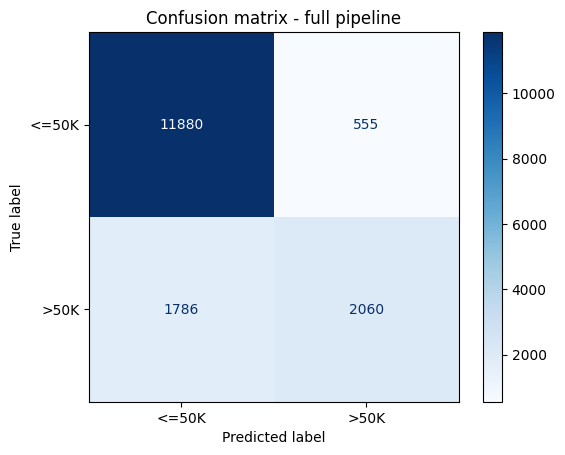

In [6]:
y_pred = full_pipeline.predict(df_test)
y_proba = full_pipeline.predict_proba(df_test)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_encoder.classes_, cmap='Blues')
plt.title("Confusion matrix - full pipeline")
plt.show()

Le pipeline complet obtient un F1-score de 0.638 et un ROC-AUC de 0.909, contre respectivement
0.669 et 0.915 pour VT_RF en Phase 4 (`max_depth=16`). L'écart s'explique directement par la
réduction volontaire de `max_depth` (16 → 8) décidée en section 4 : le modèle généralise mieux (
moins d'overfitting) mais perd un peu de pouvoir prédictif sur la classe minoritaire (`>50K`), ce
qui se traduit par un recall plus faible (0.536) que le rappel attendu d'un modèle plus profond.
Ce compromis performance/robustesse est assumé : un modèle en production, réentraîné régulièrement
sur de nouvelles données, bénéficie davantage d'une bonne généralisation que d'un score maximal sur
ce seul jeu de test.

---
## 7. Sauvegarde du pipeline <a id='section-7'></a>
On sauvegarde le pipeline entraîné (et l'encodeur de cible) avec `joblib`, afin de pouvoir les
recharger et les utiliser directement sur de nouvelles données brutes.

In [7]:
import joblib

joblib.dump(full_pipeline, 'adult_income_pipeline.joblib')
joblib.dump(target_encoder, 'adult_income_target_encoder.joblib')
print("Pipeline et encodeur de cible sauvegardes.")

reloaded_pipeline = joblib.load('adult_income_pipeline.joblib')
sample = df_test.iloc[:5]
print(reloaded_pipeline.predict(sample))

Pipeline et encodeur de cible sauvegardes.
[0 0 0 1 0]


Le pipeline rechargé produit des prédictions identiques au pipeline original, confirmant que
l'objet sauvegardé est directement réutilisable en production sans dépendre des notebooks
précédents.